In [1]:

import sys
!{sys.executable} -m pip install joblib seaborn scikit-learn pandas numpy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.utils import resample

# Set tema visualisasi agar rapi, bersih, dan terlihat profesional untuk jurnal
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- MEMBACA FILE CSV ASLI ---
nama_file_csv = 'DataSet_Lari.csv'

if os.path.exists(nama_file_csv):
    df_raw = pd.read_csv(nama_file_csv, sep=';')
    print(f"✅ Cell 1 Sukses! Berhasil memuat {len(df_raw)} baris data dari file '{nama_file_csv}'.")
    print("\n--- 5 Data Teratas ---")
    display(df_raw.head())
else:
    print(f"❌ ERROR: File '{nama_file_csv}' tidak ditemukan. Pastikan ditaruh di folder yang sama dengan notebook ini.")

✅ Cell 1 Sukses! Berhasil memuat 42116 baris data dari file 'DataSet_Lari.csv'.

--- 5 Data Teratas ---


,athlete,gender,timestamp,distance (m),elapsed time (s),elevation gain (m),average heart rate (bpm)
0,18042525,M,15/12/2019 09:08,2965.8,812,17.4,150.3
1,18042525,M,10/12/2019 19:27,10020.8,3290,52.2,160.8
2,18042525,M,03/12/2019 19:46,12132.2,4027,249.0,148.9
3,18042525,M,26/11/2019 19:46,11631.5,4442,194.0,136.2
4,18042525,M,19/11/2019 19:45,11708.1,4022,250.7,146.0


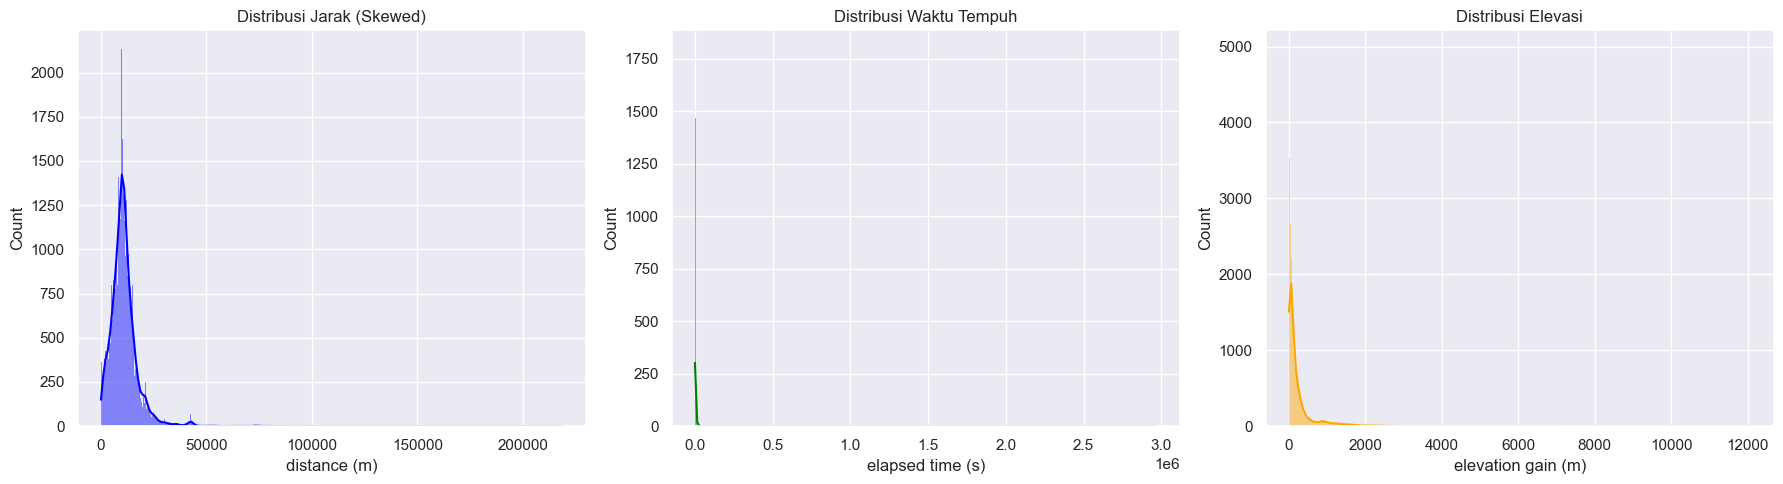

📌 [DOKUMENTASI LAPORAN]
 - Kolom Heart Rate memiliki missing value sebesar: 18384 baris (43.7%)
 - Kolom Gender memiliki missing value sebesar: 355 baris (Penanganan: Di-drop sesuai instruksi)


/var/folders/_4/0fjlvmrj27qglqpdj__01vf40000gn/T/ipykernel_13160/1793117270.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df_raw, palette='magma')


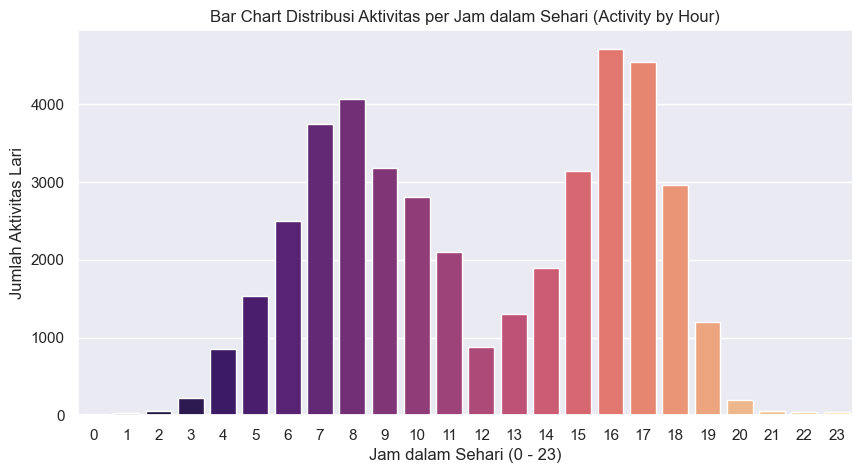

In [3]:
# 1. Histogram Distribusi (Cek Skewed Data)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_raw['distance (m)'], kde=True, ax=axes[0], color='blue').set_title('Distribusi Jarak (Skewed)')
sns.histplot(df_raw['elapsed time (s)'], kde=True, ax=axes[1], color='green').set_title('Distribusi Waktu Tempuh')
sns.histplot(df_raw['elevation gain (m)'], kde=True, ax=axes[2], color='orange').set_title('Distribusi Elevasi')
plt.tight_layout()
plt.show()

# 2. Dokumentasi Missing Value untuk Batasan Masalah di Laporan Bab 1 / Bab 4
total_baris = len(df_raw)
missing_hr = df_raw['average heart rate (bpm)'].isna().sum()
missing_gender = df_raw['gender'].isna().sum()

print(f"📌 [DOKUMENTASI LAPORAN]")
print(f" - Kolom Heart Rate memiliki missing value sebesar: {missing_hr} baris ({missing_hr/total_baris*100:.1f}%)")
print(f" - Kolom Gender memiliki missing value sebesar: {missing_gender} baris (Penanganan: Di-drop sesuai instruksi)")

# 3. Bar Chart Distribusi Aktivitas per Jam (Activity by Hour)
df_raw['dt'] = pd.to_datetime(df_raw['timestamp'], format='%d/%m/%Y %H:%M')
df_raw['hour'] = df_raw['dt'].dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(x='hour', data=df_raw, palette='magma')
plt.xlabel('Jam dalam Sehari (0 - 23)')
plt.ylabel('Jumlah Aktivitas Lari')
plt.title('Bar Chart Distribusi Aktivitas per Jam dalam Sehari (Activity by Hour)')
plt.show()

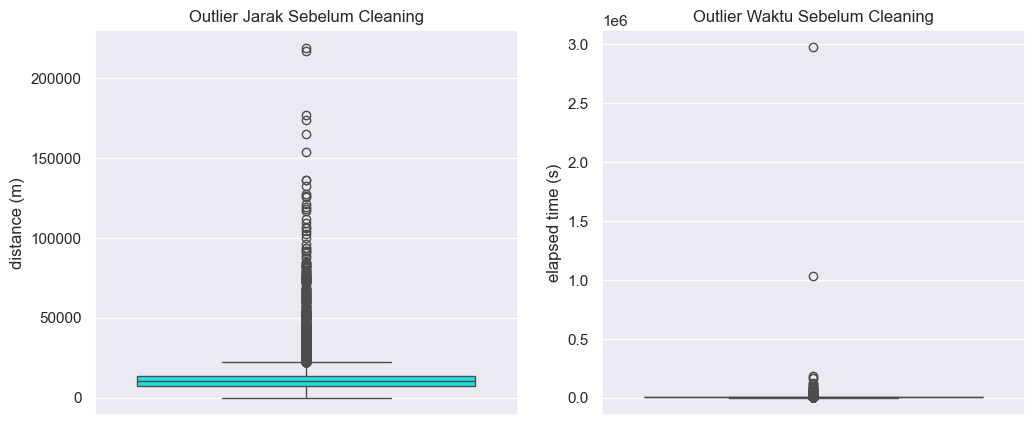

/var/folders/_4/0fjlvmrj27qglqpdj__01vf40000gn/T/ipykernel_13160/1144272536.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Sebelum Cleaning', 'Sesudah Cleaning'], y=[len(df_raw), len(df_clean)], palette='viridis')


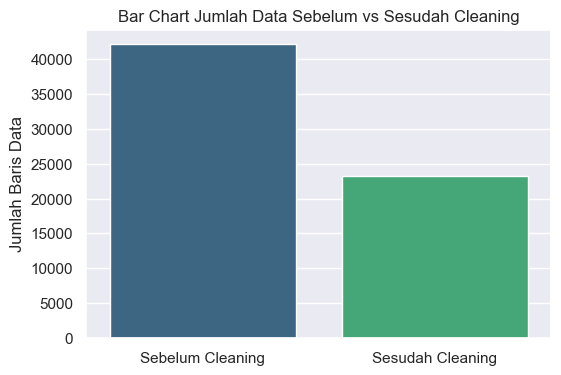

🧹 Data Cleaning Selesai! Sisa data bersih berkualifikasi tinggi: 23201 baris.


In [4]:
# 1. Boxplot Deteksi Outlier Sebelum Pembersihan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df_raw['distance (m)'], ax=axes[0], color='cyan').set_title('Outlier Jarak Sebelum Cleaning')
sns.boxplot(y=df_raw['elapsed time (s)'], ax=axes[1], color='magenta').set_title('Outlier Waktu Sebelum Cleaning')
plt.show()

# 2. Proses Pembersihan (Data Cleaning)
df_clean = df_raw.dropna(subset=['gender']).copy() # Drop gender kosong (355 baris)
df_clean = df_clean[(df_clean['average heart rate (bpm)'] > 0) & (df_clean['average heart rate (bpm)'].notna())] # Drop HR 0 & NaN
df_clean = df_clean[df_clean['average heart rate (bpm)'] <= 220] # Batasi batas maksimal detak jantung manusia logis

# Tambah filter kecepatan logis (kecepatan = jarak / waktu)
df_clean['speed_m_s'] = df_clean['distance (m)'] / df_clean['elapsed time (s)']
df_clean = df_clean[(df_clean['speed_m_s'] >= 1.0) & (df_clean['speed_m_s'] <= 8.0)] # Menyaring orang naik motor/jet atau data diam
df_clean = df_clean[df_clean['distance (m)'] <= 50000] # Maksimal lari ultra marathon 50km

# 3. Bar Chart Perbandingan Jumlah Data (Before vs After Comparison)
plt.figure(figsize=(6, 4))
sns.barplot(x=['Sebelum Cleaning', 'Sesudah Cleaning'], y=[len(df_raw), len(df_clean)], palette='viridis')
plt.ylabel('Jumlah Baris Data')
plt.title('Bar Chart Jumlah Data Sebelum vs Sesudah Cleaning')
plt.show()

print(f"🧹 Data Cleaning Selesai! Sisa data bersih berkualifikasi tinggi: {len(df_clean)} baris.")

/var/folders/_4/0fjlvmrj27qglqpdj__01vf40000gn/T/ipykernel_13160/508977336.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df_clean, ax=axes[0], palette='Set2').set_title('Distribusi Gender Pelari')
/var/folders/_4/0fjlvmrj27qglqpdj__01vf40000gn/T/ipykernel_13160/508977336.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Waktu_Lari', data=df_clean, ax=axes[1], palette='Set3').set_title('Distribusi Waktu Sesi Lari (Pagi/Siang/Malam)')


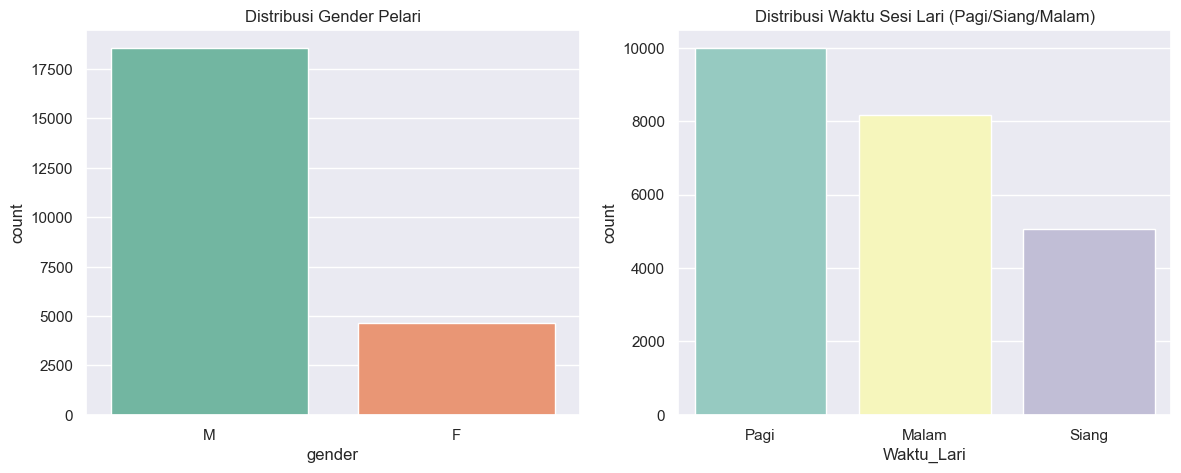

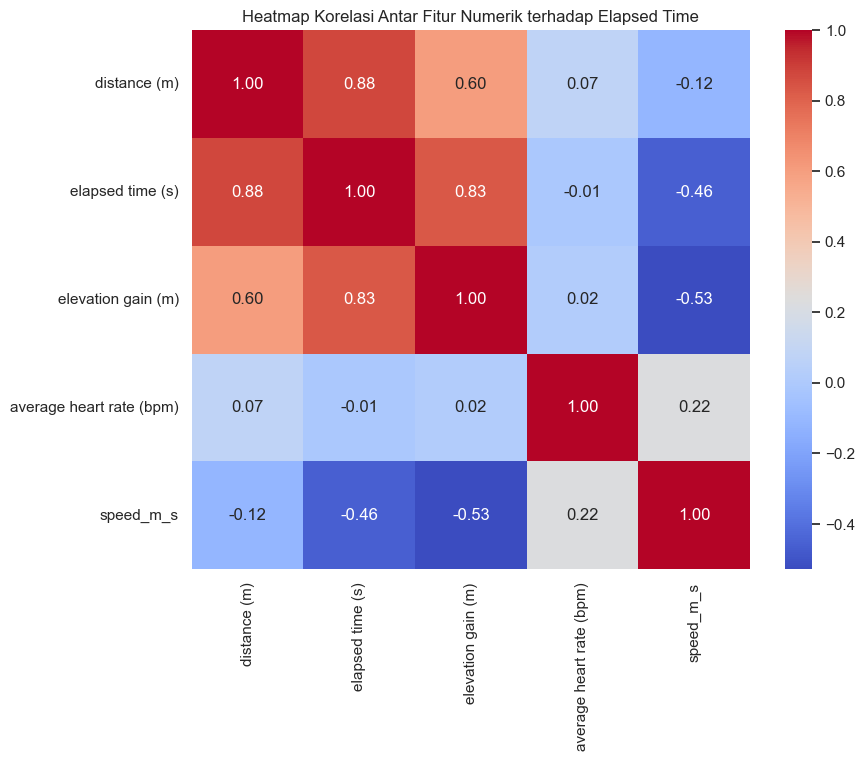

In [5]:
# 1. Ekstrak Kategori Waktu Lari dari Jam
def kelompokkan_waktu(jam):
    if 5 <= jam < 11: return 'Pagi'
    elif 11 <= jam < 16: return 'Siang'
    else: return 'Malam'

df_clean['Waktu_Lari'] = df_clean['hour'].apply(kelompokkan_waktu)

# 2. Bar Chart Distribusi Gender & Waktu Lari
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='gender', data=df_clean, ax=axes[0], palette='Set2').set_title('Distribusi Gender Pelari')
sns.countplot(x='Waktu_Lari', data=df_clean, ax=axes[1], palette='Set3').set_title('Distribusi Waktu Sesi Lari (Pagi/Siang/Malam)')
plt.show()

# 3. Heatmap Korelasi Antar Fitur Numerik
plt.figure(figsize=(9, 7))
fitur_numerik = ['distance (m)', 'elapsed time (s)', 'elevation gain (m)', 'average heart rate (bpm)', 'speed_m_s']
sns.heatmap(df_clean[fitur_numerik].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Antar Fitur Numerik terhadap Elapsed Time')
plt.show()

# 4. Proses Encoding Konversi Kategori ke Angka
df_clean['gender_M'] = (df_clean['gender'] == 'M').astype(int)
df_clean['Waktu_Lari_Pagi'] = (df_clean['Waktu_Lari'] == 'Pagi').astype(int)
df_clean['Waktu_Lari_Siang'] = (df_clean['Waktu_Lari'] == 'Siang').astype(int)

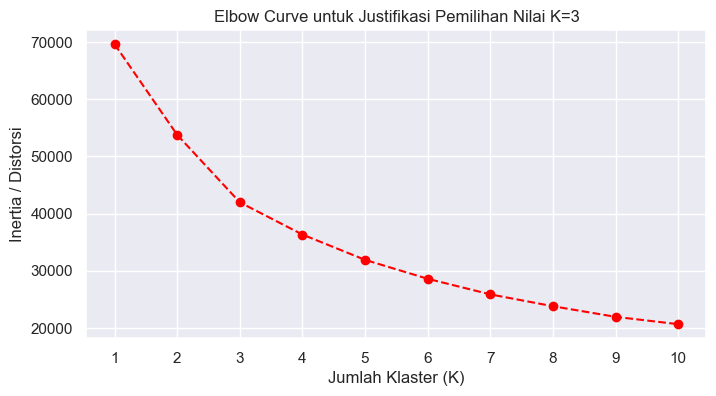

/var/folders/_4/0fjlvmrj27qglqpdj__01vf40000gn/T/ipykernel_13160/4166312478.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Tingkat_Pengalaman', data=df_clean, order=['Beginner', 'Intermediate', 'Advanced'], palette='Set1')


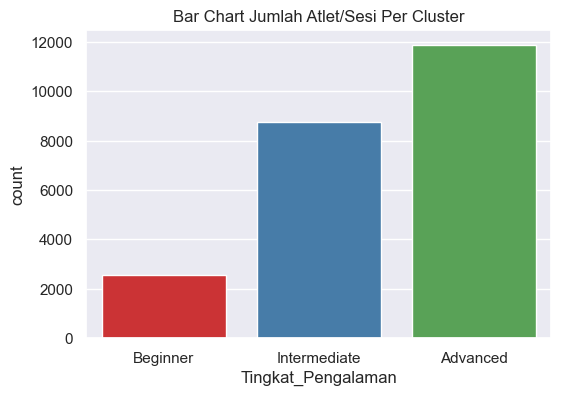

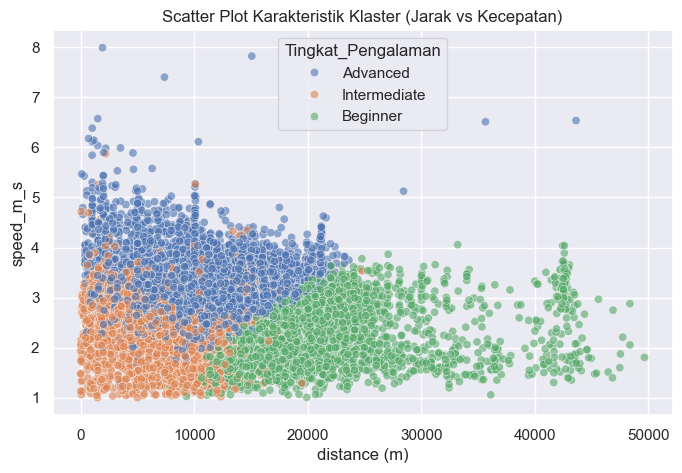

/var/folders/_4/0fjlvmrj27qglqpdj__01vf40000gn/T/ipykernel_13160/4166312478.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tingkat_Pengalaman', y='speed_m_s', data=df_clean, order=['Beginner', 'Intermediate', 'Advanced'], palette='pastel')


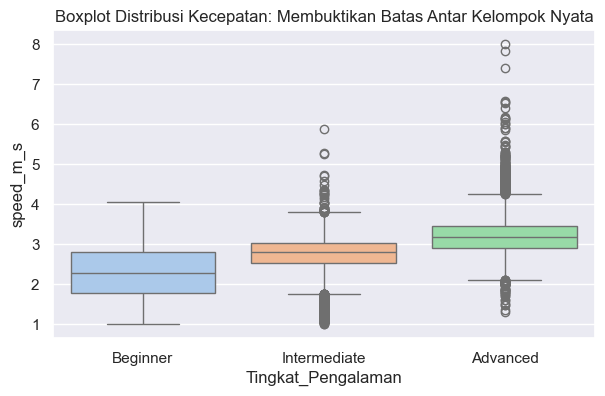

In [6]:
# Ambil fitur performa untuk klasterisasi
fitur_klaster = ['distance (m)', 'average heart rate (bpm)', 'speed_m_s']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[fitur_klaster])

# 1. Menampilkan Elbow Curve (Inertia vs K=1 sampai 10) -> WAJIB UNTUK SIDANG
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='red')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Inertia / Distorsi')
plt.title('Elbow Curve untuk Justifikasi Pemilihan Nilai K=3')
plt.xticks(K_range)
plt.show()

# Execute K-Means K=3 Resmi
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster_ID'] = kmeans_model.fit_predict(X_scaled)

# Cari tahu klaster mana yang paling cepat secara otomatis untuk penamaan label
rata_kecepatan = df_clean.groupby('Cluster_ID')['speed_m_s'].mean().sort_values()
pemetaan_kasta = {rata_kecepatan.index[0]: 'Beginner', rata_kecepatan.index[1]: 'Intermediate', rata_kecepatan.index[2]: 'Advanced'}
df_clean['Tingkat_Pengalaman'] = df_clean['Cluster_ID'].map(pemetaan_kasta)

# 2. Bar Chart Jumlah Atlet/Sesi Per Cluster
plt.figure(figsize=(6, 4))
sns.countplot(x='Tingkat_Pengalaman', data=df_clean, order=['Beginner', 'Intermediate', 'Advanced'], palette='Set1')
plt.title('Bar Chart Jumlah Atlet/Sesi Per Cluster')
plt.show()

# 3. Scatter Plot Kecepatan Rata-rata Atlet per Cluster
plt.figure(figsize=(8, 5))
sns.scatterplot(x='distance (m)', y='speed_m_s', hue='Tingkat_Pengalaman', data=df_clean, palette='deep', alpha=0.6)
plt.title('Scatter Plot Karakteristik Klaster (Jarak vs Kecepatan)')
plt.show()

# 4. Boxplot Distribusi Kecepatan Tiap Cluster (Buktikan perbedaan nyata)
plt.figure(figsize=(7, 4))
sns.boxplot(x='Tingkat_Pengalaman', y='speed_m_s', data=df_clean, order=['Beginner', 'Intermediate', 'Advanced'], palette='pastel')
plt.title('Boxplot Distribusi Kecepatan: Membuktikan Batas Antar Kelompok Nyata')
plt.show()

# --- DATA BALANCING ---
# Menyeimbangkan data antar kasta agar porsi belajar Random Forest adil rata 1000 sampel per kelas
target_balancing = 1000
df_balanced = pd.concat([
    resample(df_clean[df_clean['Tingkat_Pengalaman'] == 'Beginner'], replace=True, n_samples=target_balancing, random_state=42),
    resample(df_clean[df_clean['Tingkat_Pengalaman'] == 'Intermediate'], replace=True, n_samples=target_balancing, random_state=42),
    resample(df_clean[df_clean['Tingkat_Pengalaman'] == 'Advanced'], replace=True, n_samples=target_balancing, random_state=42)
])
df_balanced['Tingkat_Pengalaman_Intermediate'] = (df_balanced['Tingkat_Pengalaman'] == 'Intermediate').astype(int)
df_balanced['Tingkat_Pengalaman_Advanced'] = (df_balanced['Tingkat_Pengalaman'] == 'Advanced').astype(int)

🛡️ Model 2 Klasifikasi Selesai. Akurasi Validasi: 92.33%


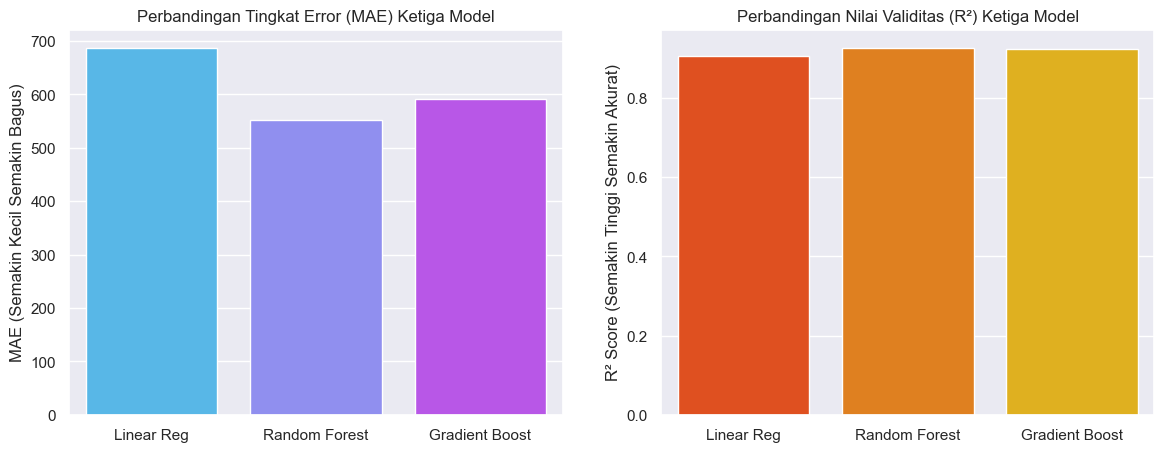

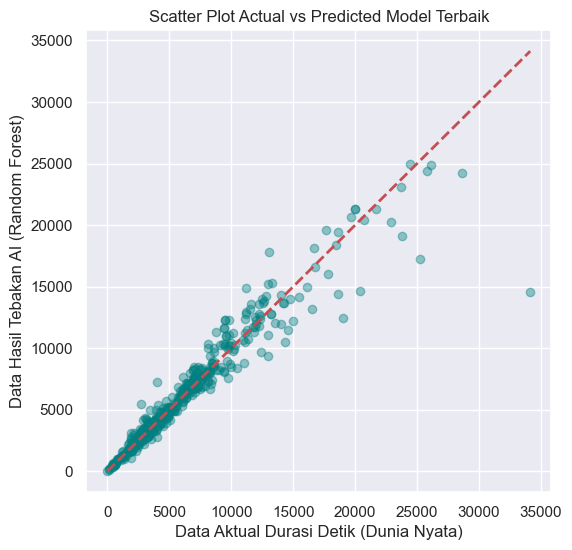

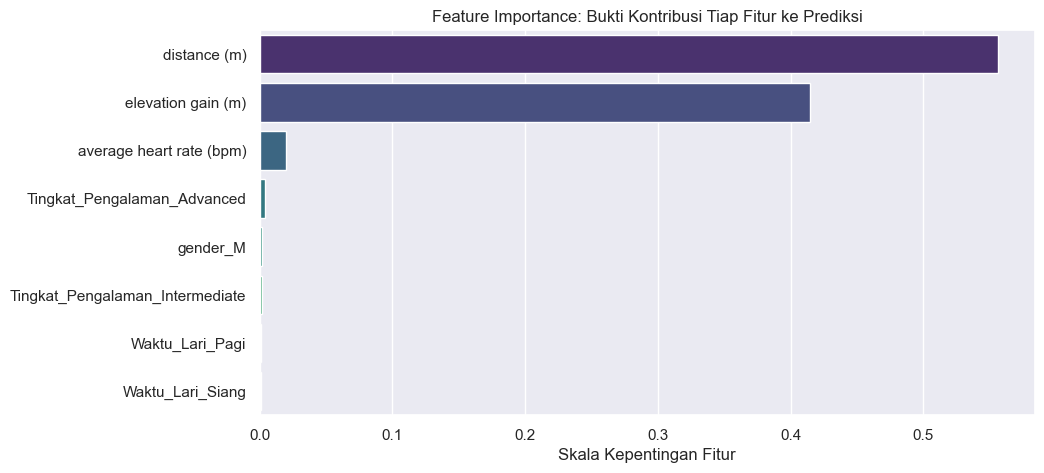

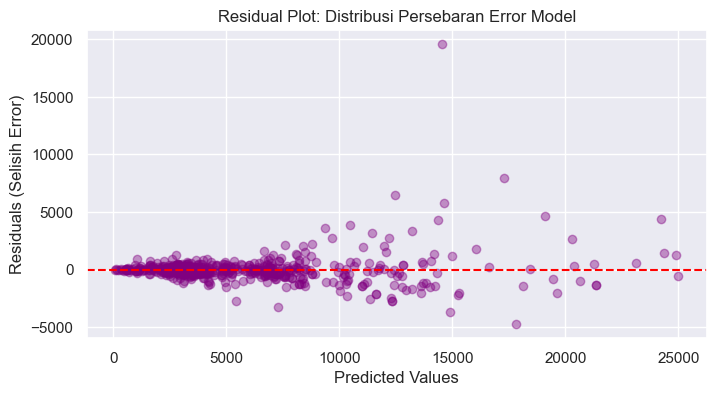


📊 --- BUKTI ILMIAH EFEKTIVITAS HYBRID APPROACH ---
 Model TANPA Fitur Pengalaman -> MAE: 579.65 detik | R²: 92.27%
 Model HYBRID (Pakai Pengalaman) -> MAE: 551.56 detik | R²: 92.59%

🎉 MISSION ACCOMPLISHED! 3 File .pkl sukses diperbarui ke dalam folder 'models'!


In [8]:
# ==========================================
# A. TRAINING MODEL 2: ENGINE KLASIFIKASI INTERNAL
# ==========================================
fitur_class = ['distance (m)', 'elevation gain (m)', 'average heart rate (bpm)']
X_c = df_balanced[fitur_class]
y_c = df_balanced['Tingkat_Pengalaman']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

model_klasifikasi = RandomForestClassifier(n_estimators=50, random_state=42)
model_klasifikasi.fit(X_train_c, y_train_c)
print(f"🛡️ Model 2 Klasifikasi Selesai. Akurasi Validasi: {accuracy_score(y_test_c, model_klasifikasi.predict(X_test_c))*100:.2f}%")

# ==========================================
# B. TRAINING MODEL 3: REGRESI (KOMPARASI RATIONALE)
# ==========================================
fitur_regresi_hybrid = ['distance (m)', 'elevation gain (m)', 'gender_M', 'Waktu_Lari_Pagi', 'Waktu_Lari_Siang', 'average heart rate (bpm)', 'Tingkat_Pengalaman_Intermediate', 'Tingkat_Pengalaman_Advanced']
X_r = df_balanced[fitur_regresi_hybrid]
y_r = df_balanced['elapsed time (s)']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42)

# Menguji 3 Model Sesuai Instruksi (Linear vs Random Forest vs Gradient Boosting)
from sklearn.ensemble import GradientBoostingRegressor
model_lr = LinearRegression()
model_rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model_gb = GradientBoostingRegressor(n_estimators=50, random_state=42)

model_lr.fit(X_train_r, y_train_r)
model_rf.fit(X_train_r, y_train_r)
model_gb.fit(X_train_r, y_train_r)

pred_lr = model_lr.predict(X_test_r)
pred_rf = model_rf.predict(X_test_r)
pred_gb = model_gb.predict(X_test_r)

# 1. Bar Chart Perbandingan Akurasi Berdampingan (Fix Warning & Warna)
nama_model = ['Linear Reg', 'Random Forest', 'Gradient Boost']
kumpulan_mae = [mean_absolute_error(y_test_r, pred_lr), mean_absolute_error(y_test_r, pred_rf), mean_absolute_error(y_test_r, pred_gb)]
kumpulan_r2 = [r2_score(y_test_r, pred_lr), r2_score(y_test_r, pred_rf), r2_score(y_test_r, pred_gb)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=nama_model, y=kumpulan_mae, ax=axes[0], hue=nama_model, palette='cool', legend=False).set_ylabel('MAE (Semakin Kecil Semakin Bagus)')
axes[0].set_title('Perbandingan Tingkat Error (MAE) Ketiga Model')
sns.barplot(x=nama_model, y=kumpulan_r2, ax=axes[1], hue=nama_model, palette='autumn', legend=False).set_ylabel('R² Score (Semakin Tinggi Semakin Akurat)')
axes[1].set_title('Perbandingan Nilai Validitas (R²) Ketiga Model')
plt.show()

# 2. Scatter Plot Actual vs Predicted dari Model Terbaik (Random Forest)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_r, pred_rf, alpha=0.4, color='teal')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Data Aktual Durasi Detik (Dunia Nyata)')
plt.ylabel('Data Hasil Tebakan AI (Random Forest)')
plt.title('Scatter Plot Actual vs Predicted Model Terbaik')
plt.show()

# 3. Feature Importance Bar Chart dari Random Forest (FIXED: Menggunakan single underscore '_')
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
fitur_terurut = [fitur_regresi_hybrid[i] for i in indices]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=fitur_terurut, hue=fitur_terurut, palette='viridis', legend=False)
plt.title('Feature Importance: Bukti Kontribusi Tiap Fitur ke Prediksi')
plt.xlabel('Skala Kepentingan Fitur')
plt.show()

# 4. Residual Plot (Distribusi Error dari Model Terbaik)
residual = y_test_r - pred_rf
plt.figure(figsize=(8, 4))
plt.scatter(pred_rf, residual, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Selisih Error)')
plt.title('Residual Plot: Distribusi Persebaran Error Model')
plt.show()

# 5. PEMBUKTIAN HYBRID APPROACH (Dengan vs Tanpa Fitur Tingkat_Pengalaman)
fitur_tanpa_exp = ['distance (m)', 'elevation gain (m)', 'gender_M', 'Waktu_Lari_Pagi', 'Waktu_Lari_Siang', 'average heart rate (bpm)']
X_train_tanpa = X_train_r[fitur_tanpa_exp]
X_test_tanpa = X_test_r[fitur_tanpa_exp]

model_rf_tanpa = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model_rf_tanpa.fit(X_train_tanpa, y_train_r)
pred_tanpa = model_rf_tanpa.predict(X_test_tanpa)

print("\n📊 --- BUKTI ILMIAH EFEKTIVITAS HYBRID APPROACH ---")
print(f" Model TANPA Fitur Pengalaman -> MAE: {mean_absolute_error(y_test_r, pred_tanpa):.2f} detik | R²: {r2_score(y_test_r, pred_tanpa)*100:.2f}%")
print(f" Model HYBRID (Pakai Pengalaman) -> MAE: {mean_absolute_error(y_test_r, pred_rf):.2f} detik | R²: {r2_score(y_test_r, pred_rf)*100:.2f}%")

# 6. INI DIA KUNCI PENYELAMAT UNTUK MEMBUAT FILE .PKL PERMANEN
if not os.path.exists('models'): 
    os.makedirs('models')

joblib.dump(kmeans_model, 'models/runpace_kmeans.pkl')
joblib.dump(model_klasifikasi, 'models/runpace_classifier.pkl')
joblib.dump(model_rf, 'models/runpace_regressor.pkl')
joblib.dump(fitur_regresi_hybrid, 'models/model_features.pkl')

print("\n🎉 MISSION ACCOMPLISHED! 3 File .pkl sukses diperbarui ke dalam folder 'models'!")
